In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d
import time

In [29]:
from scipy.stats import binned_statistic_2d
import time
   

def parse_obj_sampled(obj_path, sample_size=5000):
    start_time = time.time()
    
    vertices = []
    faces = []
    with open(obj_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            if line.startswith("v "):
                p = line.split()
                vertices.append([float(p[1]), float(p[2]), float(p[3])])

            elif line.startswith("f "):
                face = []
                for t in line.split()[1:]:
                    face.append(int(t.split("/")[0]))  # vertex index only
                faces.append(face)

    V = np.asarray(vertices, dtype=np.float64)

    nverts = len(V)
    nfaces = len(faces)

    def resolve(i):
        return (i - 1) if i > 0 else (nverts + i)

    triangle_normals = []
    triangle_areas = []

    # Randomly sample faces instead of processing all
    if nfaces > sample_size:
        sampled_indices = np.random.choice(nfaces, size=sample_size, replace=False)
        print(f"Randomly sampling {sample_size} faces out of {nfaces} total faces")
    else:
        sampled_indices = range(nfaces)
        print(f"Processing all {nfaces} faces (less than sample size)")

    # progress setup
    next_report = 0
    report_step = max(1, len(sampled_indices) // 20)  # ~5% steps

    for count, fi in enumerate(sampled_indices):
        if count >= next_report:
            pct = 100.0 * count / max(1, len(sampled_indices))
            print(f"processing faces: {pct:5.1f}% ({count}/{len(sampled_indices)})")
            next_report += report_step

        face = faces[fi]
        if len(face) < 3:
            continue

        idx = [resolve(i) for i in face]
        v0 = V[idx[0]]

        for k in range(1, len(idx) - 1):
            v1 = V[idx[k]]
            v2 = V[idx[k + 1]]

            n = np.cross(v1 - v0, v2 - v0)
            nn = np.linalg.norm(n)
            if nn <= 1e-12:
                continue

            triangle_normals.append(n / nn)
            triangle_areas.append(0.5 * nn)

    triangle_normals = np.asarray(triangle_normals, dtype=np.float64)
    triangle_areas = np.asarray(triangle_areas, dtype=np.float64)

    end_time = time.time()
    runtime = end_time - start_time

    # ---- final stats ----
    print(f"OBJ parsing runtime: {runtime:.2f} seconds")



    print(f"processing faces: {100.0:5.1f}% ({len(sampled_indices)}/{len(sampled_indices)})")
    print(f"\nLoaded OBJ: {len(vertices)} vertices")
    print(f"Generated: {len(triangle_normals)} triangle faces from {len(sampled_indices)} sampled faces")
    print(f"Sample size used: {len(sampled_indices)}")

    n = triangle_normals
    a = triangle_areas

    # component ranges (sanity checking they should be normalized already)
    print("  min/max nx:", float(n[:, 0].min()), float(n[:, 0].max()))
    print("  min/max ny:", float(n[:, 1].min()), float(n[:, 1].max()))
    print("  min/max nz:", float(n[:, 2].min()), float(n[:, 2].max()))

    # --- area stats ---
    print("\ntriangle areas:")
    print("  min/mean/max:", float(a.min()), float(a.mean()), float(a.max()))
    print("  total area:", float(a.sum()))

    # dominance
    a_sorted = np.sort(a)
    total_area = float(a_sorted.sum())
    top1 = float(a_sorted[int(0.99 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    top01 = float(a_sorted[int(0.999 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    print(f"  area in top 1% triangles:  {100.0 * top1:.2f}%")
    print(f"  area in top 0.1% triangles:{100.0 * top01:.2f}%")

    # area-weighted mean normal
    m = (n * a[:, None]).sum(axis=0)
    m_norm = np.linalg.norm(m)
    m_unit = m / m_norm
    print("\narea-weighted mean normal:")
    print("  m_unit:", m_unit)
    print("  alignment with +Z (dot):", float(m_unit[2]))

    return triangle_normals, triangle_areas


# this method will take an .obj and return the triangle face normals and areas
def parse_obj(obj_path):

    
    start_time = time.time()

    vertices = []
    faces = []
    with open(obj_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            if line.startswith("v "):
                p = line.split()
                if len(p) >= 4:  # Ensure we have at least 4 elements: 'v', x, y, z
                    vertices.append([float(p[1]), float(p[2]), float(p[3])])
                else:
                    print(f"Warning: Malformed vertex line: '{line}'")

            elif line.startswith("f "):
                face = []
                for t in line.split()[1:]:
                    face.append(int(t.split("/")[0]))  # vertex index only
                faces.append(face)

    V = np.asarray(vertices, dtype=np.float64)

    nverts = len(V)
    nfaces = len(faces)

    def resolve(i):
        return (i - 1) if i > 0 else (nverts + i)

    triangle_normals = []
    triangle_areas = []

    # progress setup
    next_report = 0
    report_step = max(1, nfaces // 20)  # ~5% steps

    for fi, face in enumerate(faces):
        if fi >= next_report:
            pct = 100.0 * fi / max(1, nfaces)
            print(f"processing faces: {pct:5.1f}% ({fi}/{nfaces})")
            next_report += report_step

        if len(face) < 3:
            continue

        idx = [resolve(i) for i in face]
        v0 = V[idx[0]]

        for k in range(1, len(idx) - 1):
            v1 = V[idx[k]]
            v2 = V[idx[k + 1]]

            n = np.cross(v1 - v0, v2 - v0)
            nn = np.linalg.norm(n)
            if nn <= 1e-12:
                continue

            triangle_normals.append(n / nn)
            triangle_areas.append(0.5 * nn)


    triangle_normals = np.asarray(triangle_normals, dtype=np.float64)
    triangle_areas = np.asarray(triangle_areas, dtype=np.float64)

    
    end_time = time.time()
    runtime = end_time - start_time
    print(f"OBJ parsing runtime: {runtime:.2f} seconds")

    # ---- final stats ----
    print(f"processing faces: {100.0:5.1f}% ({nfaces}/{nfaces})")
    print(f"\nLoaded OBJ: {len(vertices)} vertices")
    print(f"Generated: {len(triangle_normals)} triangle faces")

    n = triangle_normals
    a = triangle_areas

    # component ranges (sanity checking they should be normalized already)
    print("  min/max nx:", float(n[:, 0].min()), float(n[:, 0].max()))
    print("  min/max ny:", float(n[:, 1].min()), float(n[:, 1].max()))
    print("  min/max nz:", float(n[:, 2].min()), float(n[:, 2].max()))

    # --- area stats ---
    print("\ntriangle areas:")
    print("  min/mean/max:", float(a.min()), float(a.mean()), float(a.max()))
    print("  total area:", float(a.sum()))

    # dominance
    a_sorted = np.sort(a)
    total_area = float(a_sorted.sum())
    top1 = float(a_sorted[int(0.99 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    top01 = float(a_sorted[int(0.999 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    print(f"  area in top 1% triangles:  {100.0 * top1:.2f}%")
    print(f"  area in top 0.1% triangles:{100.0 * top01:.2f}%")

    # area-weighted mean normal
    m = (n * a[:, None]).sum(axis=0)
    m_norm = np.linalg.norm(m)
    m_unit = m / m_norm
    print("\narea-weighted mean normal:")
    print("  m_unit:", m_unit)
    print("  alignment with +Z (dot):", float(m_unit[2]))

    return triangle_normals, triangle_areas


## Convert normals to NDF x,y coordinates
def normals_to_ndf_xy(n):
    nx = n[:, 0]
    ny = n[:, 1]
    nz = n[:, 2]  # removed abs() since we'll filter negative z values before calling this
    theta = np.arccos(nz)
    phi = np.arctan2(ny, nx)
    x = np.cos(phi) * np.sin(theta)
    y = np.sin(phi) * np.sin(theta)
    return x, y

def create_ndf_histogram_from_obj(face_normals, face_areas, object_path,img, img_title=False, bins=100):
    # Filter out normals with negative z values
    valid_mask = face_normals[:, 2] >= 0
    filtered_normals = face_normals
    filtered_areas = face_areas/sum(face_areas)  # Normalize areas for better visualization
    
    print(f"Filtered {np.sum(~valid_mask)} normals with negative z values")
    print(f"Using {len(filtered_normals)} normals for NDF histogram")
    
    x, y = normals_to_ndf_xy(filtered_normals)
    
    H, xedges, yedges, _ = binned_statistic_2d(
        x, y, 
        values=filtered_areas,
        statistic='sum',
        bins=bins,
        range=[[-1, 1], [-1, 1]]
    )
    
    H = (H - np.nanmin(H)) / (np.nanmax(H) - np.nanmin(H))


    plt.figure(figsize=(10, 8))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


    img_cropped = img[img.shape[0]//2 - 250:img.shape[0]//2 + 250, img.shape[1]//2 - 250:img.shape[1]//2 + 250] 
    ax1.imshow(img_cropped)
    if img_title:   
        ax1.set_title(f'3D render of a {object_path} Surface')
    else:
        ax1.set_title(f'Microscope image of {object_path}')
    ax1.axis('off') 

   

    # Display NDF histogram
    # Add small value to avoid log(0) issues
   
    plt.imshow(H, extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
    plt.colorbar(label='Normalized Area Density')
    plt.xlabel("sin(θ)cos(ϕ)")
    plt.ylabel("sin(θ)sin(ϕ)") 
    plt.title(f'Normal Distribution Function for a {object_path} Surface')
    plt.axis('equal')
    plt.show()

    
    
    return H, xedges, yedges

# NOT IN USE
# NOT IN USE
# NOT IN USE
def smooth(H, sigma=1.2):
    # Create coordinate arrays based on H dimensions
    height, width = H.shape
    x = np.linspace(-1, 1, width)
    y = np.linspace(-1, 1, height)
    Xc, Yc = np.meshgrid(x, y, indexing="ij")
    
    # Create disk mask
    disk = (Xc * Xc + Yc * Yc) <= 1.0
    
    # Apply Gaussian smoothing
    H_num = gaussian_filter(H * disk, sigma=sigma, mode="constant", cval=0.0)
    H_den = gaussian_filter(disk.astype(np.float64), sigma=sigma, mode="constant", cval=0.0)
    H_smooth = np.where(H_den > 1e-12, H_num / H_den, 0.0)
    
    return H_smooth

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.66 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.9125875660162936 0.9106164704912962
  min

<Figure size 1000x800 with 0 Axes>

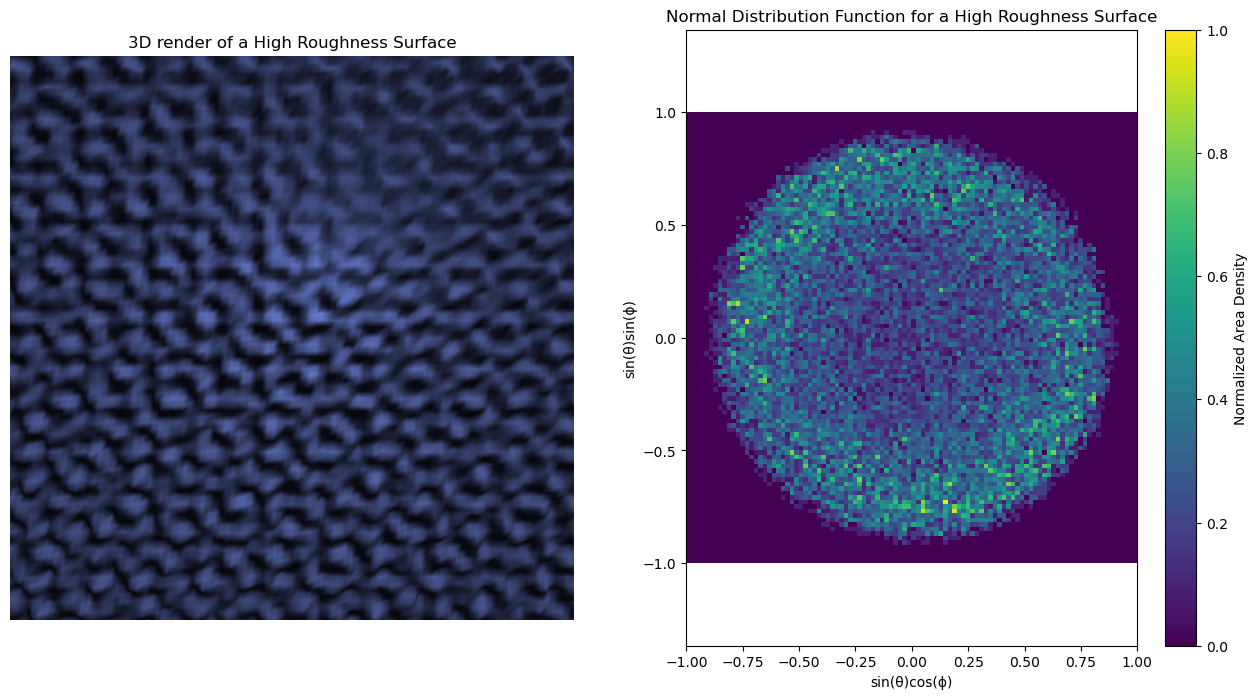

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.68 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.40203996568482475 0.41596479628897526
  m

<Figure size 1000x800 with 0 Axes>

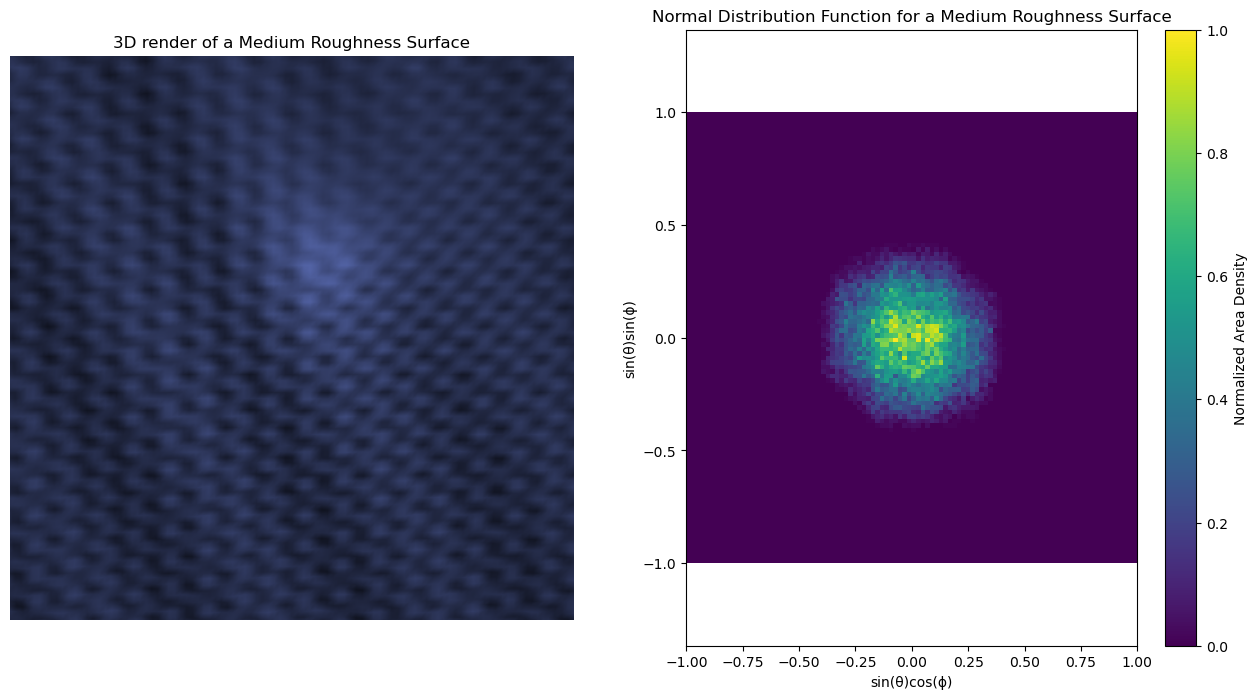

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.68 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.18558407674658434 0.2042995653514904
  mi

<Figure size 1000x800 with 0 Axes>

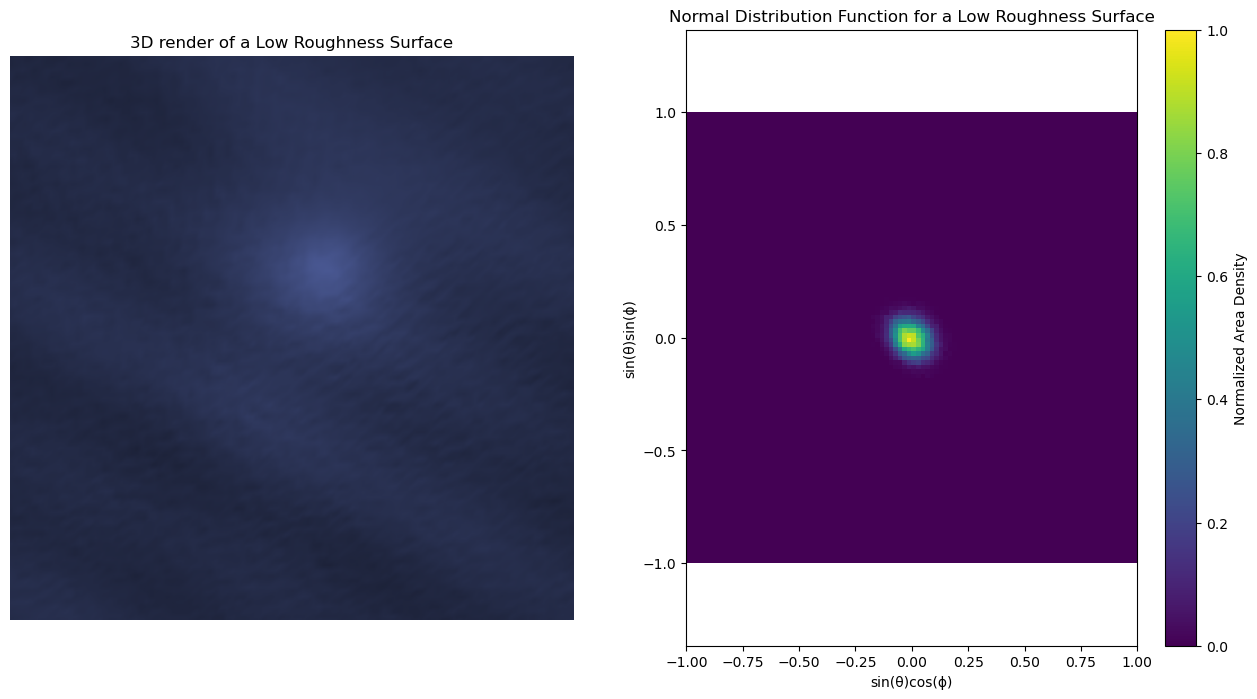

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.67 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.029049338479025095 0.03237861667071265
  

<Figure size 1000x800 with 0 Axes>

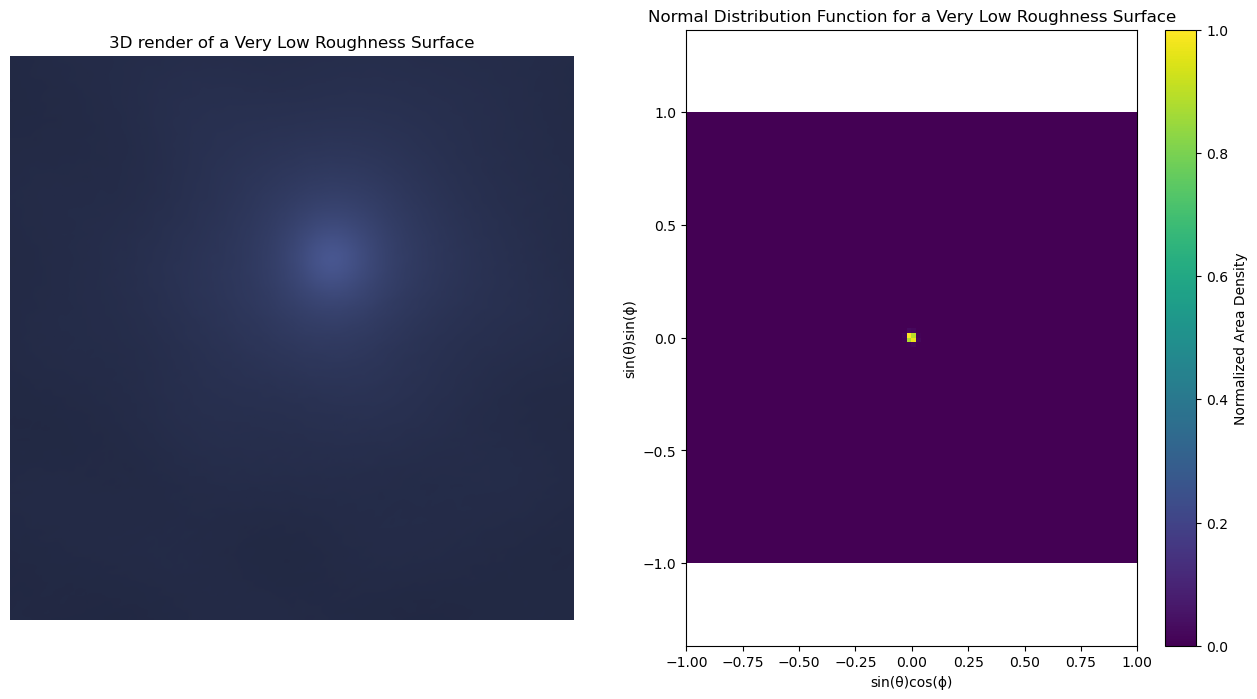

In [30]:
surfaces=[8,9,10,11]
surface_names=["High Roughness", "Medium Roughness", "Low Roughness", "Very Low Roughness"]

for surface in surfaces:
    OBJ_PATH = f"surface_{surface}.obj"  
    img = plt.imread(f"wavetype_{surface}.png")  # Load corresponding 

    triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
    H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, surface_names[surfaces.index(surface)], img, True)

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.15 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.8940091270012049 0

<Figure size 1000x800 with 0 Axes>

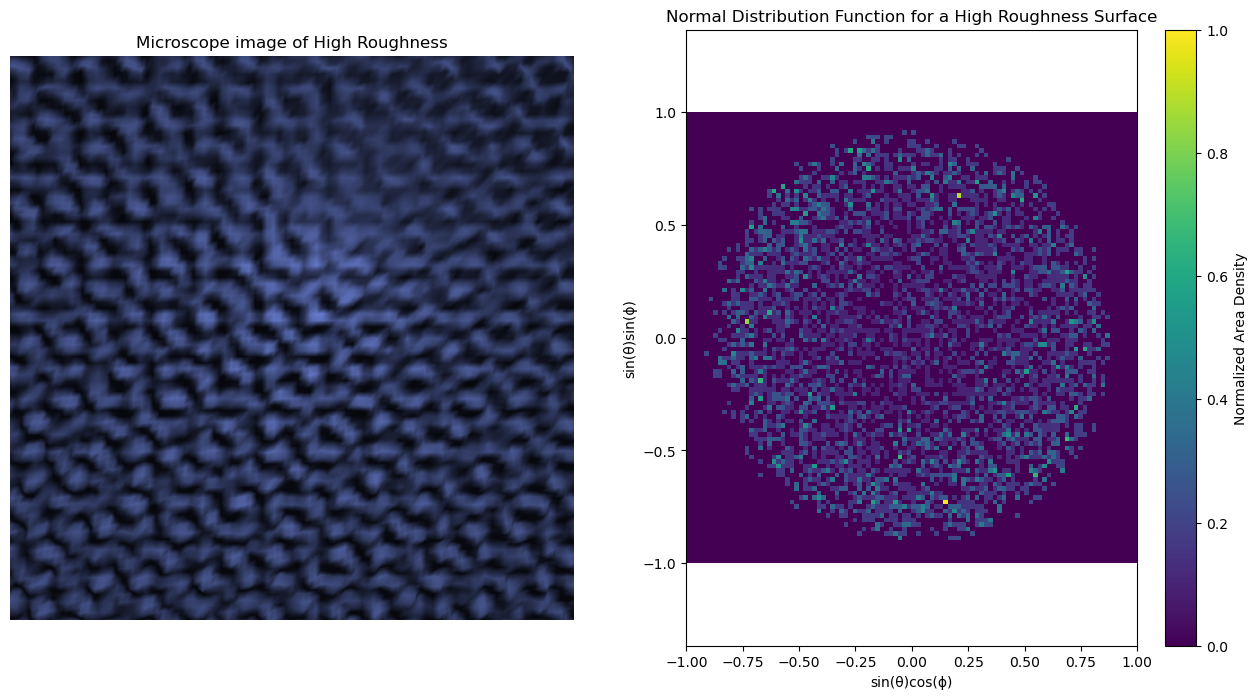

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.15 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.3873529616217426 0

<Figure size 1000x800 with 0 Axes>

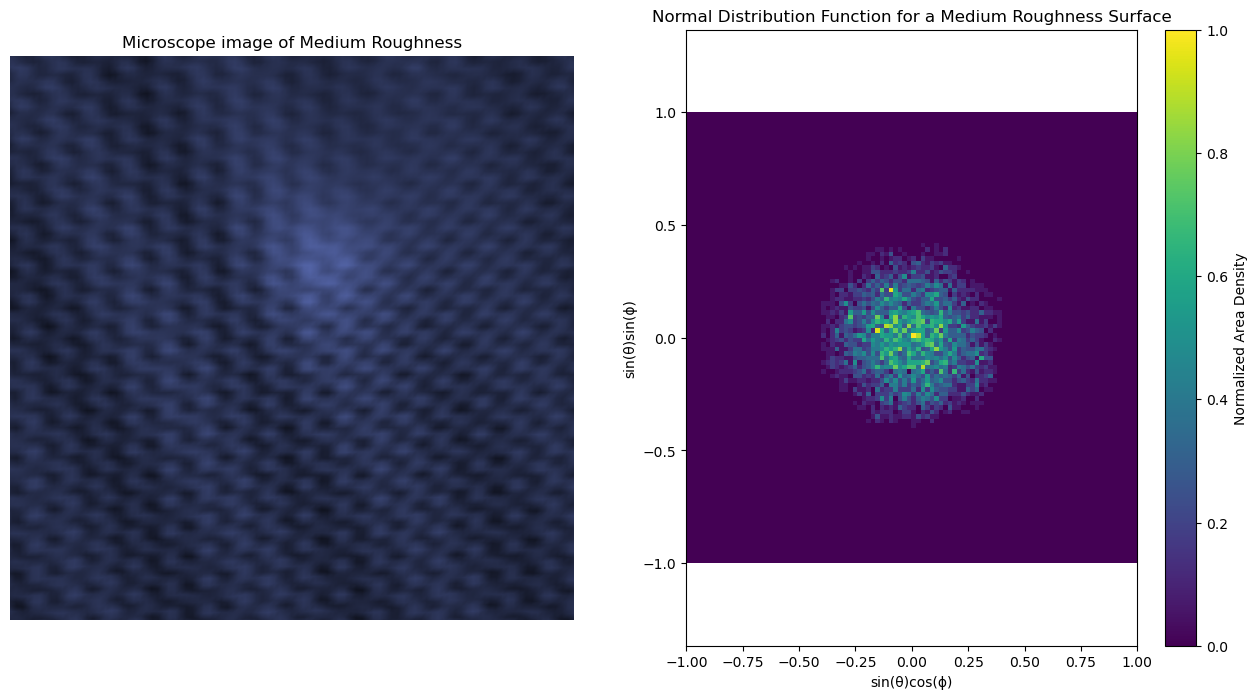

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.15 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.17465811763416889 

<Figure size 1000x800 with 0 Axes>

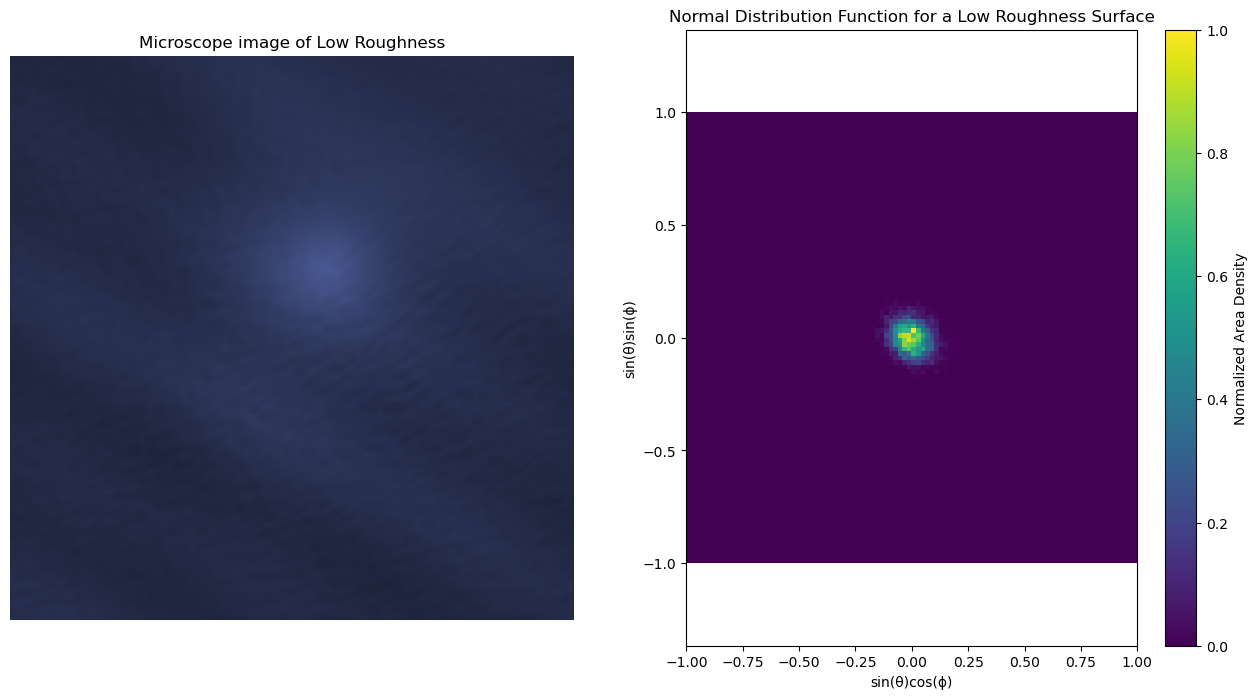

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.14 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.026137823799004492

<Figure size 1000x800 with 0 Axes>

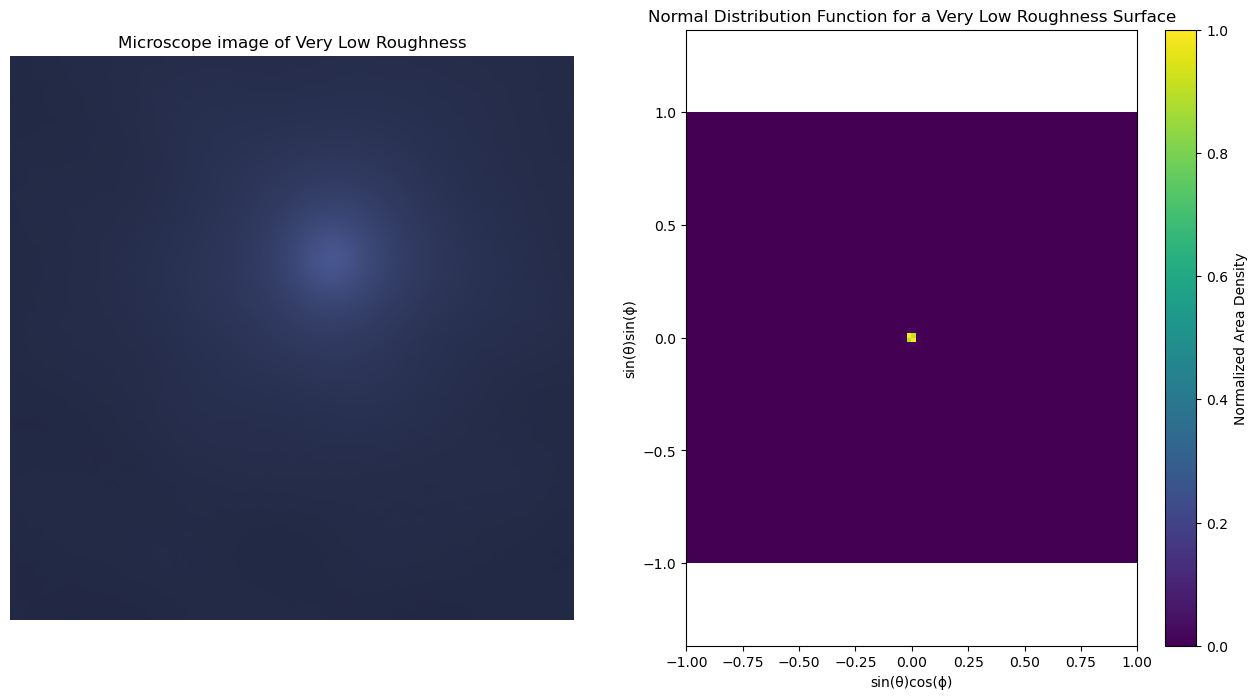

In [31]:
for surface in surfaces:
    OBJ_PATH = f"surface_{surface}.obj"  
    img = plt.imread(f"wavetype_{surface}.png")  # Load corresponding image
    triangle_normals, triangle_areas = parse_obj_sampled(OBJ_PATH)
    H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, surface_names[surfaces.index(surface)], img)

In [32]:
OBJ_PATH = "acrylic.obj"  
img = plt.imread(f"acrylic.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Acrylic', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)


KeyboardInterrupt: 

In [ ]:
OBJ_PATH = "pine.obj"  
img = plt.imread(f"pine.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Pine', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)


KeyboardInterrupt: 

In [ ]:
OBJ_PATH = "nylon.obj"  
img = plt.imread(f"nylon.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Nylon', img)

KeyboardInterrupt: 

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 39.70 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

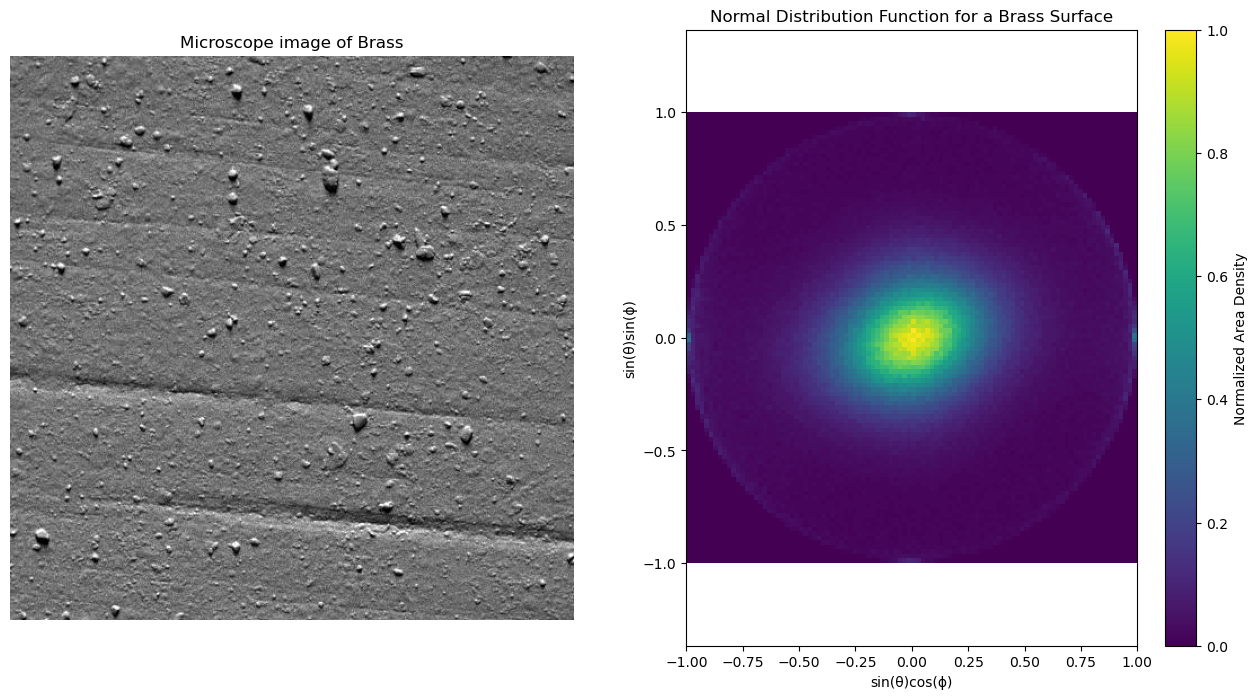

In [ ]:
OBJ_PATH = "brass.obj"  
img = plt.imread(f"brass.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Brass', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 39.92 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

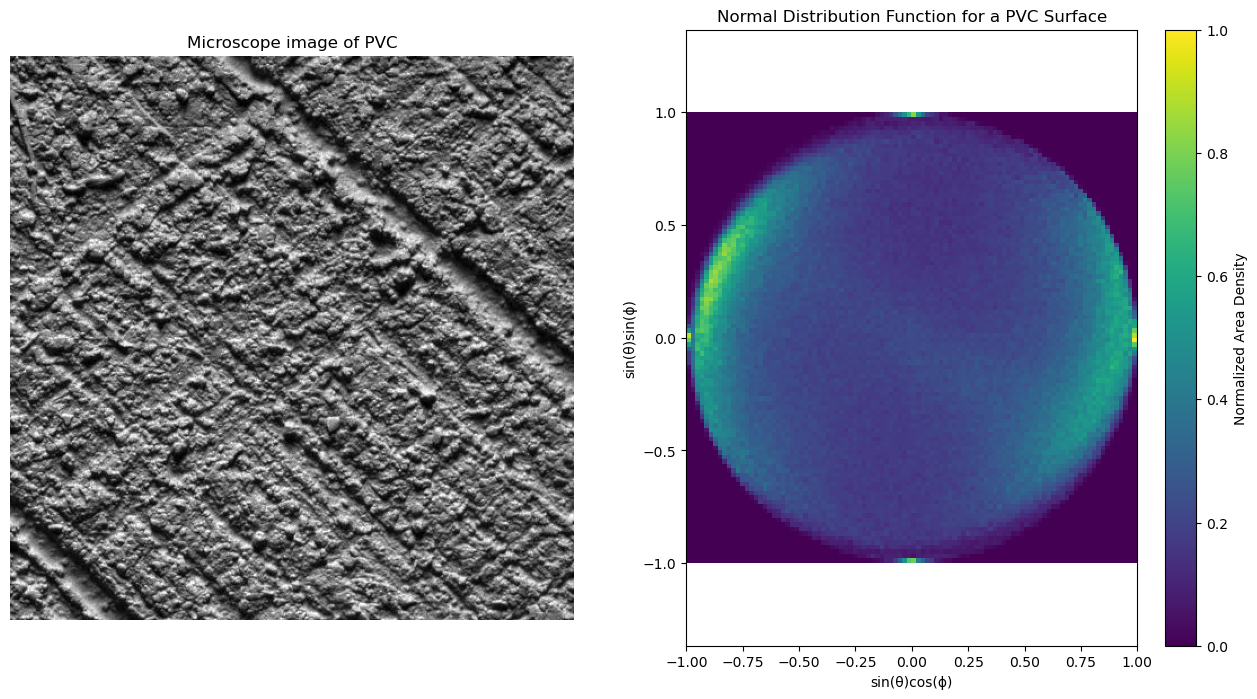

In [ ]:
OBJ_PATH = "pvc.obj"  
img = plt.imread(f"pvc.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'PVC', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 39.57 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

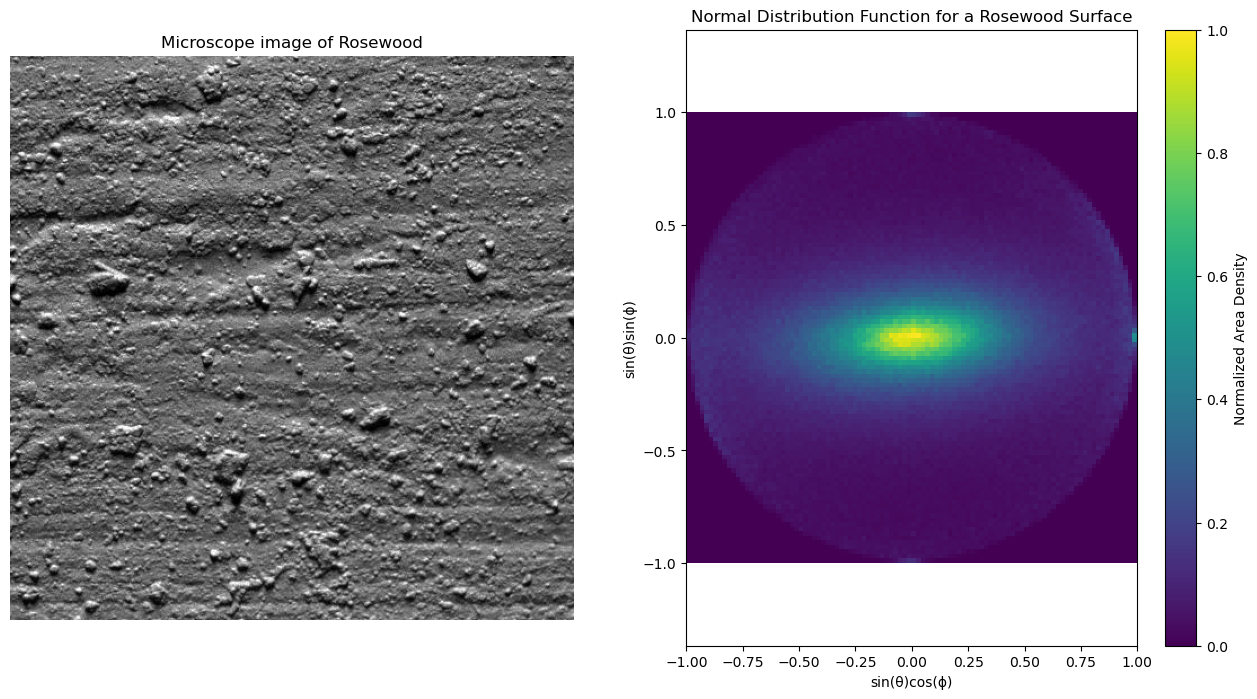

In [ ]:
OBJ_PATH = "rosewood.obj"  
img = plt.imread(f"rosewood.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Rosewood', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 39.48 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

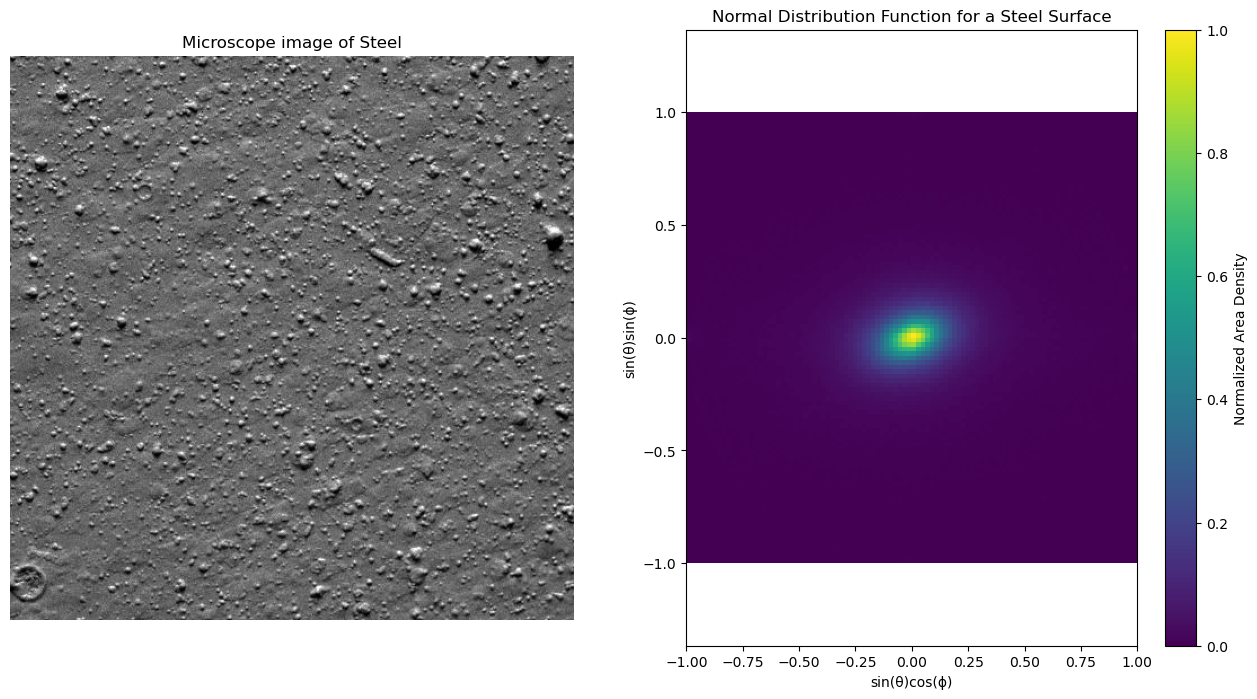

In [ ]:
OBJ_PATH = "steel.obj"  
img = plt.imread(f"steel.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Steel', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 40.09 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

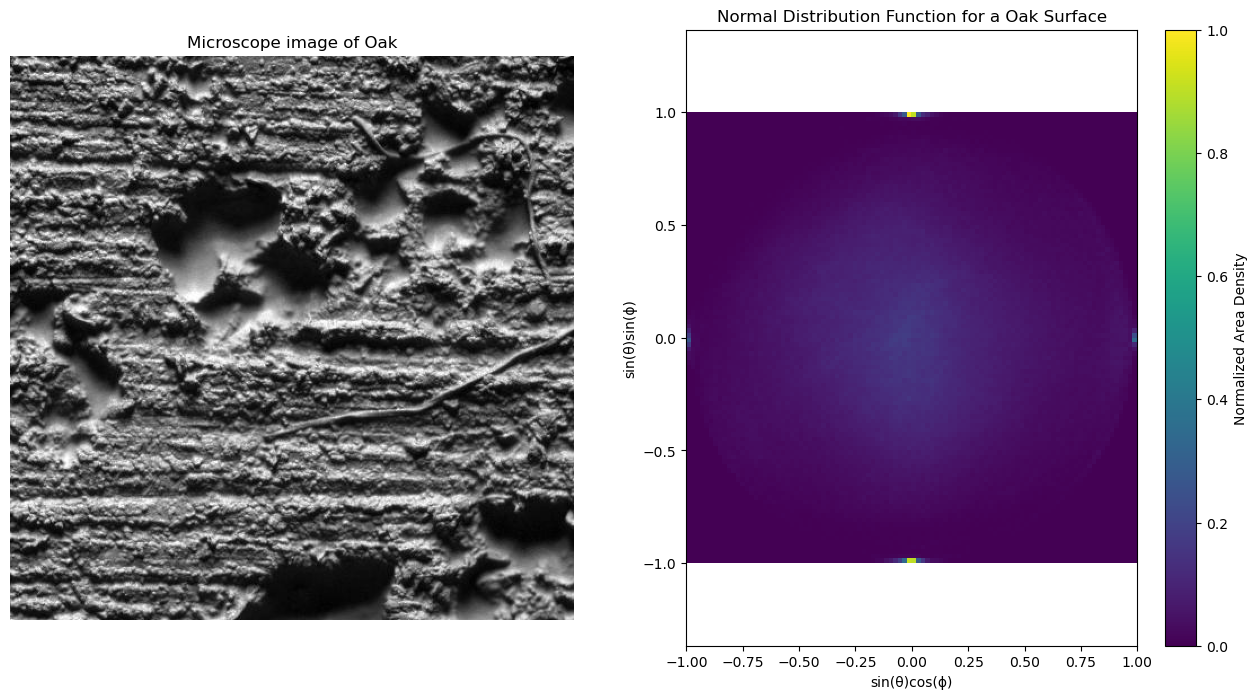

In [ ]:
OBJ_PATH = "oak.obj"  
img = plt.imread(f"oak.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Oak', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 40.11 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

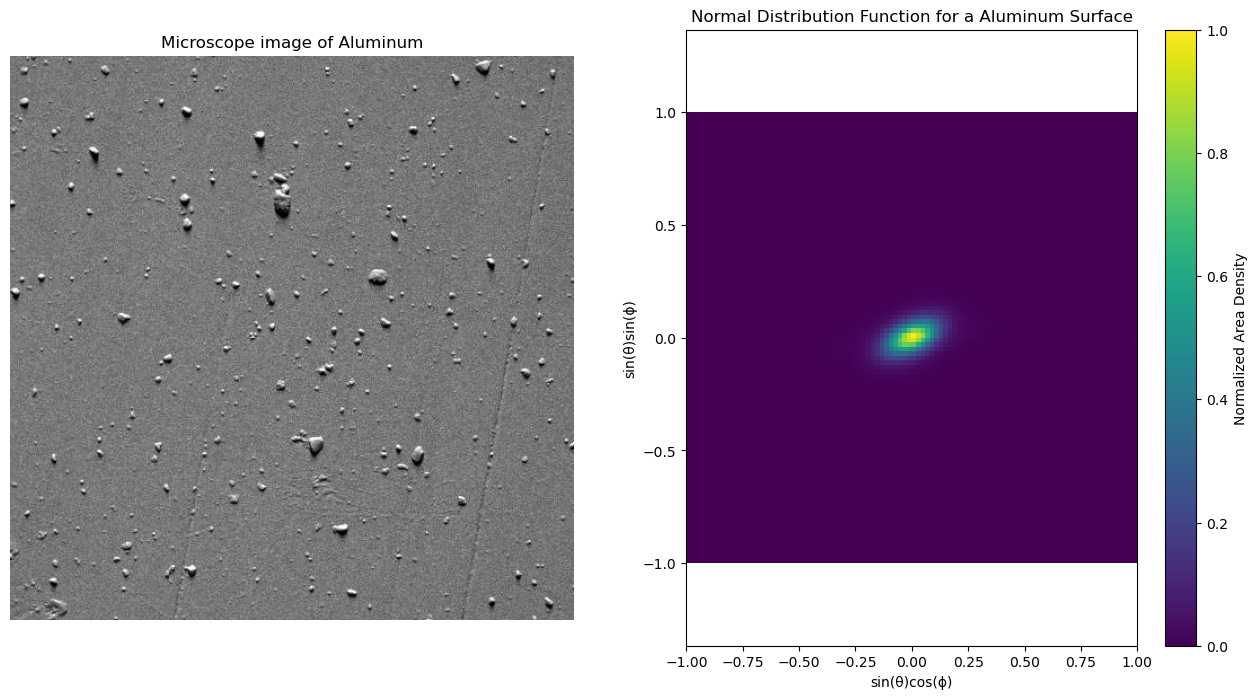

In [ ]:
OBJ_PATH = "aluminum.obj"  
img = plt.imread(f"aluminum.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Aluminum', img)

In [33]:
from scipy.ndimage import rotate

# Friction model using NDF slide+integrate overlap
# Based on JavaScript implementation from friction.js

class Friction:
    def __init__(self, surface1_data, surface2_data, rotation):

        # Surface data
        self.surface1_data = surface1_data
        self.surface2_data = surface2_data
        
        # Parameters 
        self.k = 1.0  # Friction coefficient scaling
        self.bins = 100 # Number of bins
        
        self.FN = 1  # Normal force - weight * gravitational constant
        self.Fref = 1 # Reference force - example frictional force for reference, weight*friction coefficient
        self.alpha = 1  # Load scaling exponent

        self.taps = 256  # Number of integration samples
        self.num_dirs = 180  # Number of directional samples
        
        # Build NDF grids with peak normalization
        self.ndf_grid1 = self._build_grid(
            surface1_data['ndf_samples'], 
            surface1_data['area_weights'], 
            self.bins
        )
        self.ndf_grid2 = self._build_grid(
            surface2_data['ndf_samples'], 
            surface2_data['area_weights'], 
            self.bins
        )

        if rotation==0:
            print("no rotation applied")
        else: 
            self.ndf_grid2 = self._rotate_grid(self.ndf_grid2, angle_degrees=rotation)

        # Calculate load scaling factor
        self.load_scaling = np.power(self.FN / self.Fref, self.alpha) 
        print(self.load_scaling)
        
        
        # Cache directional profile
        self.directional_profile_cache = self.directional_profile()
    
    def directional_profile(self):
        """
        Calculate friction cone.
        Returns: dict with 'angles' and 'mus'
        """
        angles = np.linspace(0, 2*np.pi, self.num_dirs, endpoint=False)
        mus = np.zeros(self.num_dirs, dtype=float)

        # compute raw directional friction
        for i, angle in enumerate(angles):
            mus[i] = self.k * self._overlap_1d(angle, self.taps) * self.load_scaling

        self.directional_profile_cache = {"angles": angles, "mus": mus}
        return self.directional_profile_cache

    
    def get_mu_at_angle(self, angle):
        """
        Get friction coefficient at a specific angle from the friction cone    
        Args:
            angle: Angle in radians
        Returns:
            Friction coefficient mu at the given angle
        """
        if self.directional_profile_cache is None:
            self.directional_profile()
        
        # Normalize angle to [0, 2π) range
        normalized_angle = ((angle % (2 * np.pi)) + 2 * np.pi) % (2 * np.pi)
        
        # Find closest index
        index = int(np.floor((normalized_angle / (2 * np.pi)) * len(self.directional_profile_cache['angles'])))
        index = np.clip(index, 0, len(self.directional_profile_cache['mus']) - 1)
        
        return self.directional_profile_cache['mus'][index]
    
    def _build_grid(self, samples, weights, bins):
        """
        Build a normalized 2D grid from sample points and weights within a unit disk.
        
        Args:
            samples: Array of sample points with x,y coordinates (Nx2)
            weights: Array of weights for each sample (N,) or None
            bins: Number of bins per dimension
            
        Returns:
            Normalized grid of size bins×bins
        """
        grid = np.zeros((bins, bins), dtype=np.float32)
        bin_size = 2.0 / bins
        
        # Convert samples to numpy array if needed
        if not isinstance(samples, np.ndarray):
            samples = np.array(samples)
        
        # Accumulate sample weights into bins (ignore samples outside unit disk)
        for i in range(len(samples)):
            x, y = samples[i, 0], samples[i, 1]
            w = weights[i] if weights is not None else 1.0
            
            # Skip samples outside unit disk
            if x*x + y*y > 1.0:
                continue
            
            # Convert to bin coordinates
            bx = int(np.floor((x + 1.0) / bin_size))
            by = int(np.floor((y + 1.0) / bin_size))
            
            # Check bounds
            if bx < 0 or bx >= bins or by < 0 or by >= bins:
                continue
            
            grid[by, bx] += w
        
        # PEAK (L∞) normalization: max value becomes 1 (if nonzero)
        max_val = np.max(grid)
        if max_val > 0:
            grid = grid / max_val
        
        return grid
    
    def _rotate_grid(self, grid, angle_degrees=90):
        """
        Rotate a 2D grid by the specified angle.
        
        Args:
            grid: 2D array to rotate
            angle_degrees: Rotation angle in degrees (default: 90)
            
        Returns:
            Rotated grid
        """
        if angle_degrees % 90 == 0:
            # Use fast rotation for multiples of 90 degrees
            k = int((angle_degrees % 360) / 90)
            return np.rot90(grid, k=-k)
        else:
            # Use interpolation-based rotation for arbitrary angles
            return rotate(grid, -angle_degrees, reshape=False, mode='constant', cval=0)

    
    def _sample_grid(self, grid, bins, x, y):
        """
        Bilinear interpolation from a grid at (x,y) ∈ [-1,1]^2.
        Returns 0 outside unit disk.
        
        Args:
            grid: 2D array to sample from
            bins: Number of bins per dimension
            x, y: Coordinates to sample at
            
        Returns:
            Interpolated value
        """
        if x*x + y*y > 1.0:
            return 0.0  # Outside disk → no contribution
        
        # Map [-1,1] → [0, bins-1]
        u = (x + 1.0) * 0.5 * (bins - 1)
        v = (y + 1.0) * 0.5 * (bins - 1)
        
        x0, y0 = int(np.floor(u)), int(np.floor(v))
        x1, y1 = min(x0 + 1, bins - 1), min(y0 + 1, bins - 1)
        
        tx, ty = u - x0, v - y0
        
        # Bilinear interpolation
        c00 = grid[y0, x0]
        c10 = grid[y0, x1]
        c01 = grid[y1, x0]
        c11 = grid[y1, x1]
        
        c0 = c00 * (1 - tx) + c10 * tx
        c1 = c01 * (1 - tx) + c11 * tx
        
        return c0 * (1 - ty) + c1 * ty
    
    def _overlap_1d(self, u_angle, taps):
        """
        1D overlap integral along direction u_angle.
        Evaluates numerically: ∫_{t=-1}^{1} f1(t·u) · f2(-t·u) dt
        
        Args:
            u_angle: The angle (in radians) defining the integration direction
            taps: The number of sample points for numerical integration
            
        Returns:
            The computed overlap integral value
        """
        g1 = self.ndf_grid1
        g2 = self.ndf_grid2
        bins = self.bins
        
        # Direction from angle
        ux = np.cos(u_angle)
        uy = np.sin(u_angle)
        
        t_max = 1.0  # integration from -1 to 1
        dt = (2 * t_max) / max(1, taps - 1)
        
        total = 0.0
        for i in range(taps):
            t = -t_max + i * dt
            
            # Surface 1: along +u
            x1 = t * ux
            y1 = t * uy
            
            # Surface 2: mirrored along -u
            x2 = -t * ux
            y2 = -t * uy
            
            f1 = self._sample_grid(g1, bins, x1, y1)
            f2 = self._sample_grid(g2, bins, x2, y2)
            
            # Weighting: more weight for t<0, less for t>0
            weight = 1.0 - t
            
            total += weight * f1 * f2
        
        return total * dt
    
    def plot_directional_friction(self, title="Directional Friction Profile"):
        """
        Plot the directional friction coefficient profile with improved aesthetics
        """
        profile = self.directional_profile_cache
        if profile is None:
            profile = self.directional_profile()

        angles = profile["angles"]
        mus = profile["mus"]

        fig, ax = plt.subplots(
            figsize=(9, 8),
            subplot_kw=dict(projection="polar"),
            constrained_layout=True
        )

        # Polar orientation (more intuitive)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        # Plot
        ax.plot(angles, mus, linewidth=2)
        ax.fill(angles, mus, alpha=0.3)

        # Limits & ticks
        rmax = np.max(mus) * 1.15
        ax.set_ylim(0, rmax)
        ax.set_rlabel_position(135)
        ax.tick_params(labelsize=10)

        # Grid styling
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

        # Title
        ax.set_title(title, fontsize=14, pad=30, y=1.08)

        # Statistics
        max_mu = np.max(mus)
        min_mu = np.min(mus)
        mean_mu = np.mean(mus)
        anisotropy = max_mu / min_mu

        stats_text = (
            r"$\mu_{\max}$" + f" = {max_mu:.3f}\n"
            r"$\mu_{\min}$" + f" = {min_mu:.3f}\n"
            r"$\mu_{\mathrm{mean}}$" + f" = {mean_mu:.3f}\n"
            r"$\mu_{\max}/\mu_{\min}$" + f" = {anisotropy:.2f}"
        )

        ax.text(
            0.02, 0.98,
            stats_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.4", alpha=0.85)
        )

        plt.show()
        return fig, ax


def create_surface_data_from_obj(obj_path, sample_size=None):
    """
    Helper function to create surface data dictionary from OBJ file
    
    Args:
        obj_path: Path to OBJ file
        sample_size: Optional sample size for large meshes
        
    Returns:
        Dictionary with 'ndf_samples' and 'area_weights'
    """
    if sample_size is not None:
        triangle_normals, triangle_areas = parse_obj_sampled(obj_path, sample_size)
    else:
        triangle_normals, triangle_areas = parse_obj(obj_path)
    
    # Filter out normals with negative z values
    valid_mask = triangle_normals[:, 2] >= 0
    filtered_normals = triangle_normals[valid_mask]
    filtered_areas = triangle_areas[valid_mask]
    
    # Convert to NDF coordinates
    x, y = normals_to_ndf_xy(filtered_normals)
    ndf_samples = np.column_stack([x, y])
    
    return {
        'ndf_samples': ndf_samples,
        'area_weights': filtered_areas
    }

In [34]:
surface1_data = create_surface_data_from_obj("uglytest.obj" )
surface2_data = create_surface_data_from_obj("uglytest.obj" )

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.70 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.9288873886355361 0.9483461659110284
  min

no rotation applied
1.0
1.0
1.0


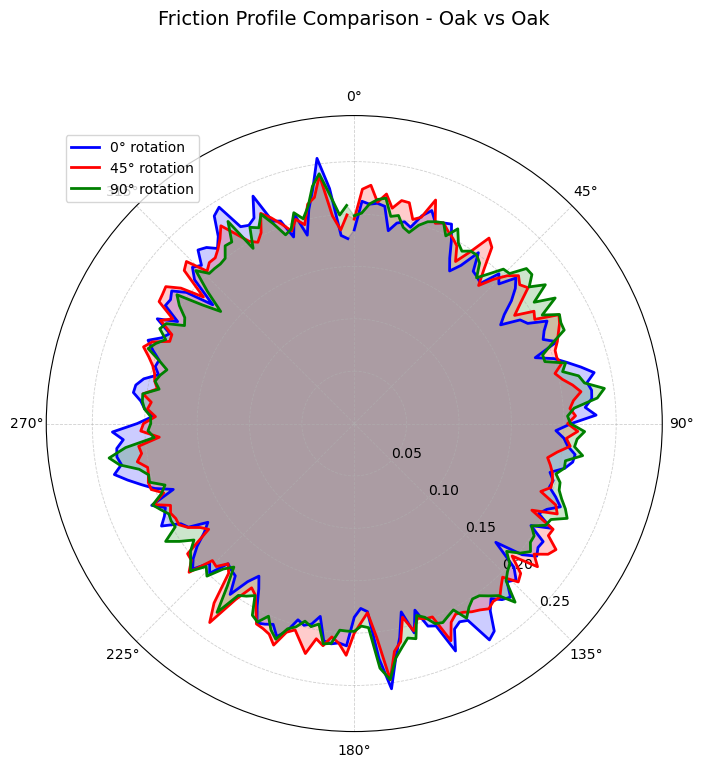

In [ ]:
# Example usage:
# Create friction model between two surfaces
def demo_friction_calculation(surface1_data, surface2_data, rotation_90):

    # Create friction model
    friction_model = Friction(surface1_data, surface2_data, rotation_90)
    
    # Plot directional friction profile
    #friction_model.plot_directional_friction("Pine vs Pine - Friction Cone")

    return friction_model

# Uncomment to run demo:
friction_model = demo_friction_calculation(surface1_data, surface2_data, 0) 
friction_model_rotated = demo_friction_calculation(surface1_data, surface2_data, 45)
friction_model_90 = demo_friction_calculation(surface1_data, surface2_data, 90)

# Plot all three friction profiles on the same polar plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection="polar"))

# Get profiles for all three models
profile1 = friction_model.directional_profile_cache
profile2 = friction_model_rotated.directional_profile_cache  
profile3 = friction_model_90.directional_profile_cache

angles = profile1["angles"]
mus1 = profile1["mus"]
mus2 = profile2["mus"]
mus3 = profile3["mus"]

# Plot all three profiles
ax.plot(angles, mus1, linewidth=2, label='0° rotation', color='blue')
ax.plot(angles, mus2, linewidth=2, label='45° rotation', color='red')
ax.plot(angles, mus3, linewidth=2, label='90° rotation', color='green')

# Fill areas with transparency
ax.fill(angles, mus1, alpha=0.2, color='blue')
ax.fill(angles, mus2, alpha=0.2, color='red') 
ax.fill(angles, mus3, alpha=0.2, color='green')

# Polar plot settings
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Set limits
rmax = max(np.max(mus1), np.max(mus2), np.max(mus3)) * 1.15
ax.set_ylim(0, rmax)
ax.set_rlabel_position(135)

# Styling
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.tick_params(labelsize=10)
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))

# Title
ax.set_title('Friction Profile Comparison', fontsize=14, pad=30, y=1.08)

plt.show()

